In [1]:
import qiskit
import phoenix
import json
from qiskit.quantum_info import Operator

**Load Pauli strings and coefficients from a JSON file and construct a `Hamiltonian` instance**

In [2]:
with open('../benchmarks/uccsd_json/NH_frz_JW_sto3g.json', 'r') as f:
    data = json.load(f)

M = 10
data['paulis'] = data['paulis'][:M]
data['coeffs'] = data['coeffs'][:M]
ham = phoenix.Hamiltonian(data['paulis'], data['coeffs'])
# ham = phoenix.Hamiltonian(['XXXZIYZI', 'YXXZIYYI', 'ZXXZIYZI'], [-0.0125, -0.0125, -0.0125])
u = ham.unitary_evolution()

In [3]:
ham.print_tableau() # BSF representation of the Pauli terms in the Hamiltonian

+------------------------------------------------------------+
|                   Display index: q0...q9                   |
+------------+---------------------+---------------------+---+
|   Pauli    |        X part       |        Z part       | s |
+------------+---------------------+---------------------+---+
| IIIIIIYZZX | 0 0 0 0 0 0 1 0 0 1 | 0 0 0 0 0 0 1 1 1 0 | 0 |
| IYZZXIIIII | 0 1 0 0 1 0 0 0 0 0 | 0 1 1 1 0 0 0 0 0 0 | 0 |
| IIIIIIXZZY | 0 0 0 0 0 0 1 0 0 1 | 0 0 0 0 0 0 0 1 1 1 | 0 |
| IXZZYIIIII | 0 1 0 0 1 0 0 0 0 0 | 0 0 1 1 1 0 0 0 0 0 | 0 |
| IIIIIYZZZX | 0 0 0 0 0 1 0 0 0 1 | 0 0 0 0 0 1 1 1 1 0 | 0 |
| YZZZXIIIII | 1 0 0 0 1 0 0 0 0 0 | 1 1 1 1 0 0 0 0 0 0 | 0 |
| IIIIIXZZZY | 0 0 0 0 0 1 0 0 0 1 | 0 0 0 0 0 0 1 1 1 1 | 0 |
| XZZZYIIIII | 1 0 0 0 1 0 0 0 0 0 | 0 1 1 1 1 0 0 0 0 0 | 0 |
| IIIIIIYZXI | 0 0 0 0 0 0 1 0 1 0 | 0 0 0 0 0 0 1 1 0 0 | 0 |
| IYZXIIIIII | 0 1 0 1 0 0 0 0 0 0 | 0 1 1 0 0 0 0 0 0 0 | 0 |
+------------+---------------------+-------------------

In [4]:
qc_trivial = ham.generate_circuit()
phoenix.utils.print_circ_info(qc_trivial, title='Trivial synthesized circuit')
print(qc_trivial.count_ops())
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_trivial).to_matrix()))

+----------------------------------------------------------+
|               Trivial synthesized circuit                |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |    114    |      64      |   46  |    32    |
+------------+-----------+--------------+-------+----------+
OrderedDict({'cx': 64, 'h': 20, 'sx': 10, 'rz': 10, 'sxdg': 10})


In [5]:
qc_phoenix = phoenix.compile_hamiltonian_simulation(ham, order_method='greedy')
phoenix.utils.print_circ_info(qc_phoenix, title='PHOENIX synthesized circuit')
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_phoenix).to_matrix()))
print(qc_phoenix.count_ops())

+----------------------------------------------------------+
|               PHOENIX synthesized circuit                |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |     82    |      24      |   25  |    12    |
+------------+-----------+--------------+-------+----------+
OrderedDict({'u': 58, 'cx': 24})


In [6]:
qc_phoenix = phoenix.compile_hamiltonian_simulation(ham, method='smt', optimize=False)
phoenix.utils.print_circ_info(qc_phoenix, title='PHOENIX synthesized circuit')
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_phoenix).to_matrix()))
print(qc_phoenix.count_ops())

T=1: UNSAT
T=2: UNSAT
T=3: UNSAT
T=4: UNSAT
T=5: UNSAT
T=6: SAT ✓
+----------------------------------------------------------+
|               PHOENIX synthesized circuit                |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |    238    |      25      |   38  |    10    |
+------------+-----------+--------------+-------+----------+
OrderedDict({'h': 106, 's': 49, 'sdg': 49, 'cx': 18, 'ryy': 3, 'rzx': 3, 'sx': 3, 'rz': 3, 'sxdg': 3, 'rxx': 1})


In [10]:
qc_phoenix.count_ops().get('cx', 0)

18

In [11]:
qc_phoenix.draw(fold=-1)

┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐ ┌───┐  ┌───┐     ┌───┐                                                    ┌────────────┐              ┌───────────┐┌─────┐ ┌───┐  ┌───┐  ┌─────┐┌─────┐ ┌───┐    ┌───┐   ┌─────┐ ┌───┐  ┌───┐  ┌─────┐ ┌───┐ ┌─────┐ ┌───┐                                                                       
q_0: ┤ H ├┤ S ├┤ H ├┤ S ├┤ H ├┤ H ├┤ S ├┤ H ├┤ H ├┤ S ├┤ S ├─┤ H ├──┤ H ├─────┤ S ├────────────────────────────────────────────────────┤0           ├──────────────┤0          ├┤ Sdg ├─┤ H ├──┤ H ├──┤ Sdg ├┤ Sdg ├─┤ H ├────┤ H ├───┤ Sdg ├─┤ H ├──┤ H ├──┤ Sdg ├─┤ H ├─┤ Sdg ├─┤ H ├───────────────────────────────────────────────────────────────────────
     └───┘└───┘└───┘├───┤├───┤├───┤├───┤├───┤├───┤├───┤├───┤ └───┘  └───┘ ┌───┴───┴────┐             ┌───────────┐                     │            │┌────────────┐│           │├─────┤┌┴───┴┐┌┴───┴┐ └┬───┬┘└┬───┬┘┌┴───┴┐   ├───┤   ├─────┤ └───┘  └───┘  └─────┘ └───┘ └─────┘ └───┘                                                                       
q_1: ────────────■──┤ S ├┤ H ├┤ S ├┤ H ├┤ H ├┤ S ├┤ S ├┤ S ├──────────────┤0           ├─────────────┤0          ├─────────────────────┤            ├┤0           ├┤           ├┤ Sdg ├┤ Sdg ├┤ Sdg ├──┤ H ├──┤ H ├─┤ Sdg ├───┤ H ├───┤ Sdg ├────────────────────────────────■────────────────────────────────────────────────────────────────────────────────
     ┌───┐┌───┐  │  ├───┤├───┤└───┘├───┤├───┤├───┤├───┤├───┤┌─────┐┌─────┐│            │   ┌─────┐   │           │    ┌───┐     ┌─────┐│            ││            ││           │└─────┘└─────┘└─────┘  └───┘  └───┘ └─────┘   └───┘   └─────┘               ┌─────┐ ┌───┐    │    ┌───┐ ┌─────┐                                                               
q_2: ┤ S ├┤ H ├──┼──┤ H ├┤ S ├──■──┤ S ├┤ H ├┤ S ├┤ S ├┤ S ├┤ Sdg ├┤ Sdg ├┤            ├───┤ Sdg ├───┤           ├────┤ H ├─────┤ Sdg ├┤  Rzx(-0.1) ├┤  Rzx(-0.1) ├┤  Ryy(0.1) ├───────────────────────────────────────────────────────────────────────■────┤ Sdg ├─┤ H ├────┼────┤ H ├─┤ Sdg ├───────────────────────────────────────────────────────────────
     ├───┤├───┤  │  ├───┤└───┘┌─┴─┐├───┤├───┤├───┤├───┤├───┤└┬───┬┘└┬───┬┘│  Ryy(-0.1) │   └┬───┬┘   │  Rzx(0.1) │    ├───┤     └─────┘│            ││            ││           │ ┌───┐ ┌─────┐ ┌───┐  ┌─────┐┌─────┐ ┌───┐    ┌───┐    ┌───┐ ┌─────┐ ┌─┴─┐  └┬───┬┘ ├───┤    │   ┌┴───┴┐└─────┘                                                               
q_3: ┤ S ├┤ H ├──┼──┤ H ├─────┤ X ├┤ S ├┤ H ├┤ X ├┤ H ├┤ S ├─┤ S ├──┤ H ├─┤            ├────┤ S ├────┤           ├────┤ H ├────────────┤            ├┤1           ├┤           ├─┤ H ├─┤ Sdg ├─┤ H ├──┤ Sdg ├┤ Sdg ├─┤ H ├────┤ X ├────┤ H ├─┤ Sdg ├─┤ X ├───┤ H ├──┤ H ├────┼───┤ Sdg ├──────────────────────────────────────────────────────────────────────
     ├───┤└───┘┌─┴─┐├───┤┌───┐├───┤├───┤└───┘└─┬─┘├───┤├───┤ ├───┤  └───┘ │            │    └───┘    │           │    └───┘            │            │└────────────┘│           │┌┴───┴┐└┬───┬┘ ├───┤  └─────┘└─────┘ └───┘    └─┬─┘    ├───┤ └┬───┬┘┌┴───┴┐  ├───┤  └───┘  ┌─┴─┐ └┬───┬┘                                                                      
q_4: ┤ H ├─────┤ X ├┤ H ├┤ S ├┤ H ├┤ H ├───────■──┤ H ├┤ H ├─┤ S ├────────┤1           ├─────────────┤1          ├─────────────────────┤1           ├──────────────┤1          ├┤ Sdg ├─┤ H ├──┤ H ├────────────────────────────■──────┤ H ├──┤ H ├─┤ Sdg ├──┤ H ├─────────┤ X ├──┤ H ├───────────────────────────────────────────────────────────────────────
     ├───┤┌───┐├───┤├───┤├───┤├───┤├───┤┌───┐┌───┐├───┤├───┤ ├───┤  ┌───┐ └───┬────┬───┘             └───────────┘                     └────────────┘    ┌───┐     └┬─────────┬┘└─────┘ ├───┤ ┌┴───┴─┐               ┌───┐ ┌─────────┐ └───┘  ├───┤ ├─────┤  ├───┤ ┌─────┐ ├───┤  ├───┤ ┌─────┐ ┌───┐ ┌─────┐┌─────┐ ┌───┐  ┌───┐ ┌─────┐ ┌───┐               
q_5: ┤ H ├┤ S ├┤ H ├┤ H ├┤ S ├┤ S ├┤ H ├┤ S ├┤ H ├┤ H ├┤ S ├─┤ H ├──┤ S ├─────┤ √X ├────────────────────────────────────────────────────────────

In [7]:
qc_qiskit = phoenix.utils.qiskit_pass(ham.paulis.to_labels(), ham.coeffs)
phoenix.utils.print_circ_info(qc_qiskit, title='Qiskit synthesized circuit')
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_qiskit).to_matrix()))


+----------------------------------------------------------+
|                Qiskit synthesized circuit                |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |     66    |      32      |   27  |    16    |
+------------+-----------+--------------+-------+----------+


In [8]:
qc_tket = phoenix.utils.tket_pass(ham.paulis.to_labels(), ham.coeffs, little_endian=True)
phoenix.utils.print_circ_info(qc_tket, title='TKet synthesized circuit')
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_tket).to_matrix()))

+----------------------------------------------------------+
|                 TKet synthesized circuit                 |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     10     |     66    |      24      |   15  |    9     |
+------------+-----------+--------------+-------+----------+


/Users/anan/git-projects/quantum/phoenix/phoenix/utils.py:151: ComplexWarning: Casting complex values to real discards the imaginary part
  pauli_box = PauliExpBox([pauli_str_map[pauli[q]] for q in qubits], t=coeff * 2 / np.pi)


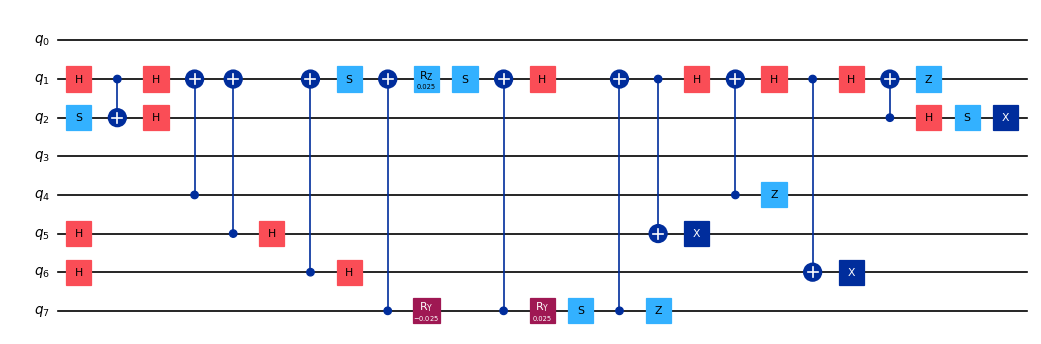

In [15]:
qc_qiskit.draw('mpl', fold=100, scale=0.6)

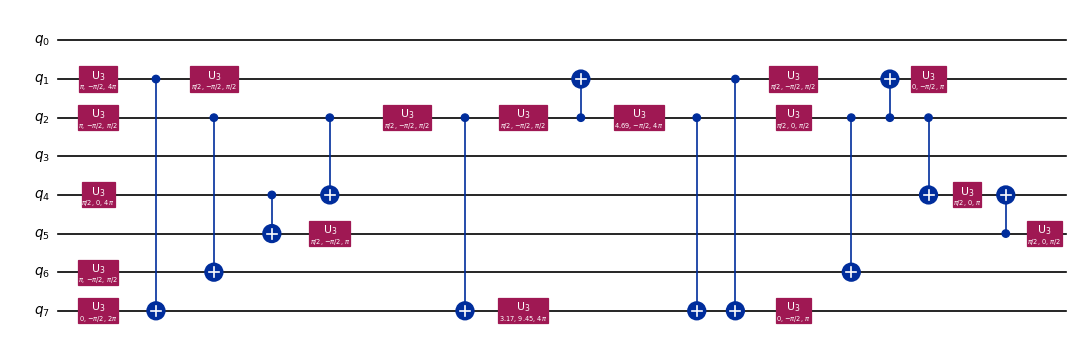

In [16]:
qc_tket.draw('mpl', fold=100, scale=0.6)

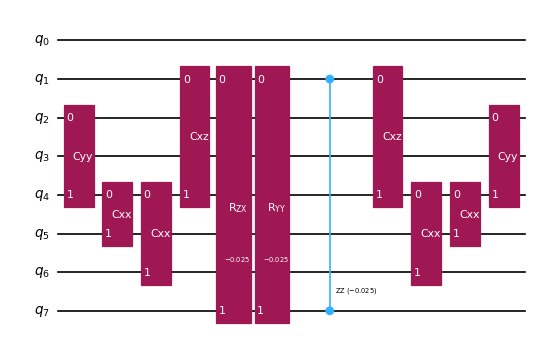

In [20]:
qc_phoenix.draw('mpl', fold=-1, scale=0.6)

In [14]:
ham.print_tableau()

+----------+-----------------+-----------------+---+
|  Pauli   |      X part     |      Z part     | s |
+----------+-----------------+-----------------+---+
| IZYIZXXX | 0 0 1 0 0 1 1 1 | 0 1 1 0 1 0 0 0 | 0 |
| IYYIZXXY | 0 1 1 0 0 1 1 1 | 0 1 1 0 1 0 0 1 | 0 |
| IZYIZXXZ | 0 0 1 0 0 1 1 0 | 0 1 1 0 1 0 0 1 | 0 |
+----------+-----------------+-----------------+---+


In [6]:
phoenix.utils.assert_equiv_circuits(qc_trivial, qc_phoenix)

In [7]:
qc_trivial.draw(fold=-1)

q_0: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                               ┌───┐┌────────────┐┌───┐┌────┐                                                  ┌───┐┌────────────┐┌───┐┌──────┐                                                    ┌───┐┌────────────┐┌───┐                            
q_1: ──────────────────────────┤ X ├┤ Rz(-0.025) ├┤ X ├┤ √X ├──────────────────────────────────────────────────┤ X ├┤ Rz(-0.025) ├┤ X ├┤ √Xdg ├────────────────────────────────────────────────────┤ X ├┤ Rz(-0.025) ├┤ X ├────────────────────────────
     ┌────┐               ┌───┐└─┬─┘└────────────┘└─┬─┘├───┬┘┌──────┐┌────┐                               ┌───┐└─┬─┘└────────────┘└─┬─┘└┬───┬─┘┌──────┐┌────┐                                 ┌───┐└─┬─┘└────────────┘└─┬─┘┌───┐┌──────┐               
q_2: ┤ √X ├───────────────┤ X ├──■──────────────────■──┤ X ├─┤ √Xdg ├┤ √X ├───────────────────────────────┤ X ├──■──────────────────■───┤ X ├──┤ √Xdg ├┤ √X ├─────────────────────────────────┤ X ├──■──────────────────■──┤ X ├┤ √Xdg ├───────────────
     └────┘               └─┬─┘                        └─┬─┘ └──────┘└────┘                               └─┬─┘                         └─┬─┘  └──────┘└────┘                                 └─┬─┘                        └─┬─┘└──────┘               
q_3: ───────────────────────┼────────────────────────────┼──────────────────────────────────────────────────┼─────────────────────────────┼─────────────────────────────────────────────────────┼────────────────────────────┼─────────────────────────
                     ┌───┐  │                            │    ┌───┐                                  ┌───┐  │                             │     ┌───┐                                    ┌───┐  │                            │   ┌───┐                 
q_4: ────────────────┤ X ├──■────────────────────────────■────┤ X ├──────────────────────────────────┤ X ├──■─────────────────────────────■─────┤ X ├────────────────────────────────────┤ X ├──■────────────────────────────■───┤ X ├─────────────────
     ┌───┐      ┌───┐└─┬─┘                                    └─┬─┘  ┌───┐ ┌───┐┌───┐           ┌───┐└─┬─┘                                      └─┬─┘  ┌───┐ ┌───┐ ┌───┐            ┌───┐└─┬─┘                                   └─┬─┘  ┌───┐┌───┐     
q_5: ┤ H ├──────┤ X ├──■────────────────────────────────────────■────┤ X ├─┤ H ├┤ H ├───────────┤ X ├──■──────────────────────────────────────────■────┤ X ├─┤ H ├─┤ H ├────────────┤ X ├──■───────────────────────────────────────■────┤ X ├┤ H ├─────
     ├───┤ ┌───┐└─┬─┘                                                └─┬─┘ ├───┤├───┤┌───┐ ┌───┐└─┬─┘                                                  └─┬─┘ ├───┤ ├───┤  ┌───┐┌───┐└─┬─┘                                               └─┬─┘├───┤┌───┐
q_6: ┤ H ├─┤ X ├──■────────────────────────────────────────────────────■───┤ X ├┤ H ├┤ H ├─┤ X ├──■──────────────────────────────────────────────────────■───┤ X ├─┤ H ├──┤ H ├┤ X ├──■───────────────────────────────────────────────────■──┤ X ├┤ H ├
     ├───┤ └─┬─┘                                                           └─┬─┘├───┤├───┴┐└─┬─┘                                                             └─┬─┘┌┴───┴─┐└───┘└─┬─┘                                                         └─┬─┘└───┘
q_7: ┤ H ├───■───────────────────────────────────────────────────────────────■──┤ H ├┤ √X ├──■─────────────────────────────────────────────────────────────────■──┤ √Xdg ├───────■─────────────────────────────────────────────────────────────■───────
     └───┘                                                                      └───┘└────┘                                                                       └──────┘

In [8]:
qc_phoenix.draw(fold=-1)

q_0: ─────────────────────────────────────────────────────────────────────────────────────────────────────────────
                             ┌──────┐┌──────────────┐┌──────────────┐             ┌──────┐                        
q_1: ────────────────────────┤0     ├┤0             ├┤0             ├─■───────────┤0     ├────────────────────────
     ┌──────┐                │      ││              ││              │ │           │      │                ┌──────┐
q_2: ┤0     ├────────────────┤      ├┤              ├┤              ├─┼───────────┤      ├────────────────┤0     ├
     │      │                │  Cxz ││              ││              │ │           │  Cxz │                │      │
q_3: ┤  Cyy ├────────────────┤      ├┤              ├┤              ├─┼───────────┤      ├────────────────┤  Cyy ├
     │      │┌──────┐┌──────┐│      ││              ││              │ │           │      │┌──────┐┌──────┐│      │
q_4: ┤1     ├┤0     ├┤0     ├┤1     ├┤  Rzx(-0.025) ├┤  Ryy(-0.025) ├─┼───────────┤1     ├┤0     ├┤0     ├┤1     ├
     └──────┘│  Cxx ││      │└──────┘│              ││              │ │           └──────┘│      ││  Cxx │└──────┘
q_5: ────────┤1     ├┤  Cxx ├────────┤              ├┤              ├─┼───────────────────┤  Cxx ├┤1     ├────────
             └──────┘│      │        │              ││              │ │                   │      │└──────┘        
q_6: ────────────────┤1     ├────────┤              ├┤              ├─┼───────────────────┤1     ├────────────────
                     └──────┘        │              ││              │ │ZZ(-0.025)         └──────┘                
q_7: ────────────────────────────────┤1             ├┤1             ├─■───────────────────────────────────────────
                                     └──────────────┘└──────────────┘